In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.losses import categorical_crossentropy
from sklearn.metrics import accuracy_score
from keras.optimizers import Adam
from keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.listdir("data"))

['fer2013.csv']


In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
data = pd.read_csv('data/fer2013.csv')
#check data shape
data.shape

(35887, 3)

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
import pandas as pd

# créer une nouvelle colonne nommée "disgust_images"
data['disgust_images'] = ""

# sélectionner les images avec la valeur 1 dans la colonne "emotion" et les déplacer vers la colonne "disgust_images"
disgust_images = data.loc[data['emotion'] == 1, 'pixels']
data.loc[data['emotion'] == 1, 'disgust_images'] = disgust_images

# supprimer les lignes avec la valeur 1 dans la colonne "emotion"
data.drop(data[data['emotion'] == 1].index, inplace=True)

# afficher la nouvelle forme du DataFrame
print(data.shape)

(35340, 4)


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
#check target labels
emotion_map = {0: 'Angry', 2:'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
emotion_counts = data['emotion'].value_counts(sort=False).reset_index()
emotion_counts.columns = ['emotion', 'number']
emotion_counts['emotion'] = emotion_counts['emotion'].map(emotion_map)
emotion_counts

,emotion,number
0,Angry,4953
1,Fear,5121
2,Sad,6077
3,Neutral,6198
4,Happy,8989
5,Surprise,4002


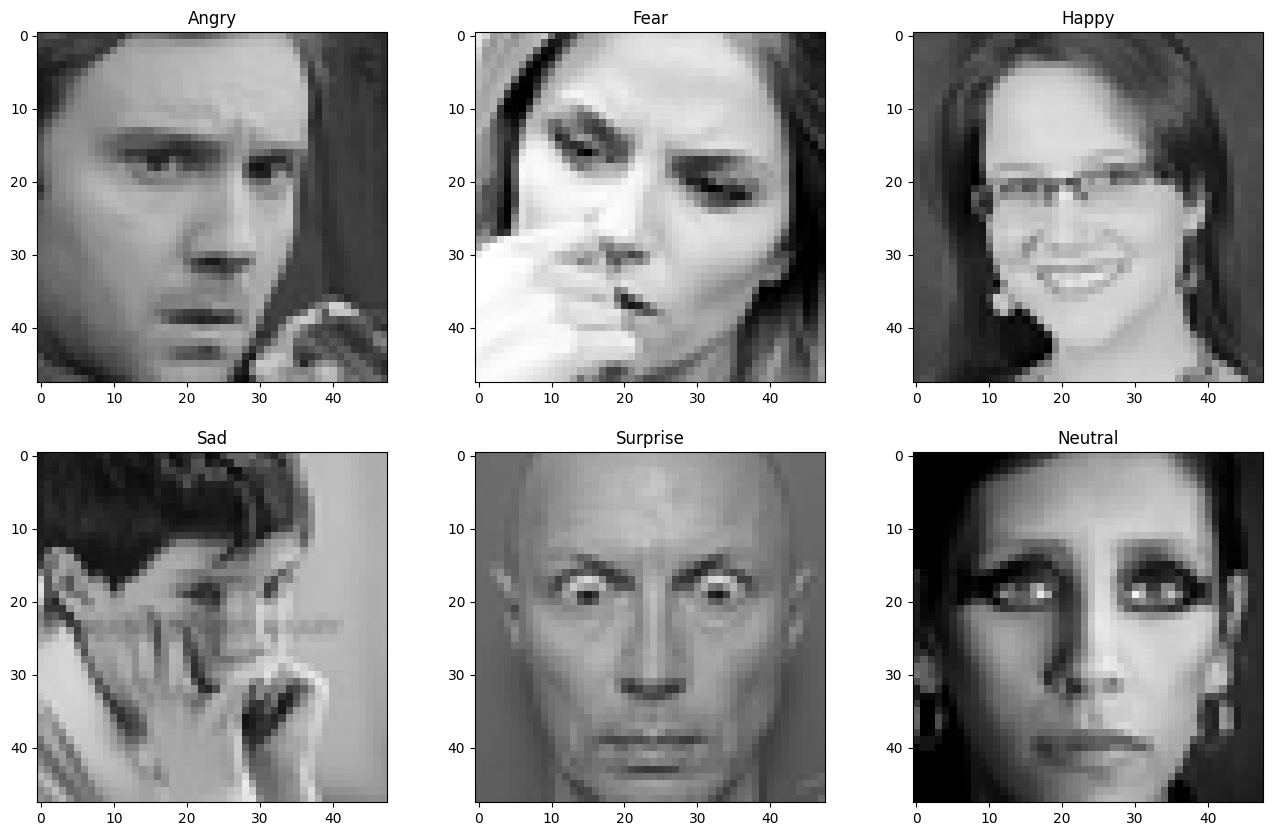

In [5]:
# --- [CELL 4]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# === BEFORE (original) ===
# def row2image(row):
#     pixels, emotion = row['pixels'], emotion_map[row['emotion']]#extrait les pixels et l'émotion de la ligne de données. Les pixels sont stockés en tant que chaîne de caractères contenant tous les pixels séparés par des espaces.
#     img = np.array(pixels.split(), dtype=np.uint8)
#     img = img.reshape((48, 48))
#     image = np.zeros((48, 48, 3), dtype=np.uint8)
#     image[:, :, 0] = img
#     image[:, :, 1] = img
#     image[:, :, 2] = img
#     # fix to reproduce the crash: tensor shape mismatch (this line would also crash)
#     return image, emotion  # return np.array([image, emotion])
# 
# plt.figure(0, figsize=(16,10))
# for i in range(1,8):
#     face = data[data['emotion'] == i-1].iloc[0]
#     # fix 1 (corresponding fixes)
#     img, label = row2image(face) # img = row2image(face)
#     plt.subplot(2,4,i)
#     plt.imshow(img[0])
#     plt.title(label) # plt.title(img[1])
# 
# plt.show()

# === AFTER (edited) ===
def row2image(row):
    pixels, emotion = row['pixels'], emotion_map[row['emotion']]
    img = np.array(pixels.split(), dtype=np.uint8)
    img = img.reshape((48, 48))
    image = np.zeros((48, 48, 3), dtype=np.uint8)
    image[:, :, 0] = img
    image[:, :, 1] = img
    image[:, :, 2] = img

    return image, emotion

# Get the list of available emotions (excluding 1 which was removed)
available_emotions = data['emotion'].unique()
available_emotions.sort()

plt.figure(0, figsize=(16,10))
for idx, emotion_id in enumerate(available_emotions[:6]):
    face = data[data['emotion'] == emotion_id].iloc[0]

    img, label = row2image(face)
    plt.subplot(2,3,idx+1)
    plt.imshow(img)
    plt.title(label)

plt.show()

In [6]:
import numpy as np
import pandas as pd

assert 'emotion' in data.columns, "Expected emotion column to exist"
assert callable(row2image), "Expected row2image to be defined in previous cell"

present_classes = set(pd.unique(data['emotion']))
missing_classes = set(range(7)) - present_classes
assert 1 in missing_classes, "Expected class 1 to be missing after disgust-row removal"

# Reproduce the fixed behavior: iterate safely over class ids and skip missing classes.
processed_classes = []
for cls in range(7):
    if cls not in present_classes:
        continue
    face = data.loc[data['emotion'] == cls].iloc[0]
    img, label = row2image(face)
    assert isinstance(img, np.ndarray), "row2image must return an ndarray image"
    assert img.shape == (48, 48, 3), f"Unexpected image shape: {img.shape}"
    assert label == emotion_map[cls], "Label must match emotion_map for the sampled class"
    processed_classes.append(cls)

assert processed_classes == sorted(present_classes), "Safe iteration should process every available class exactly once"

# Context check: the old unguarded selection pattern is unsafe for this dataset.
unguarded_raised = False
try:
    for cls in range(7):
        _ = data.loc[data['emotion'] == cls].iloc[0]
except IndexError:
    unguarded_raised = True

assert unguarded_raised, "Unguarded class iteration should fail when a class is missing"